###### Content under Creative Commons Attribution license CC-BY 3.0, code under BSD 3-Clause License © 2026  by D. Koehn, T. Meier and J. Stampa, notebook style sheet by L.A. Barba, N.C. Clementi

In [1]:
# Execute this cell to load the notebook's style sheet, then ignore it
from IPython.core.display import HTML
css_file = '../style/custom.css'
HTML(open(css_file, "r").read())

# Digital Signal Processing: Terms and Definitions

## Chapter 2 Exercises

### Exercise 2.1 

Assign the value $10^{20}$ to a floating-point variable $𝑥$. Define
a variable $𝑦$ such that $𝑦 = 𝑥 + 1$. Calculate $𝑦 − 𝑥$ and interpret the
result.

In [2]:
# Import Python libraries
# -----------------------
# %matplotlib inline
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np
#from scipy.stats import skew

In [3]:
# Define x
x = float(1e20) # define x as float

# Compute y
y = x + 1

# Compute and print y-x
print("y-x = ", y-x)

y-x =  0.0


The limited dynamic/resolution of the floating point number leads to the result y-x = 0.0. However, integers in Python can be arbritarily large, as long as enough RAM is available ([Bits, Bytes and Numbers](https://caam37830.github.io/book/00_python/bitsbytes.html)). Therefore, we get the correct result, when using Integers ...

In [4]:
# Define x
x = int(1e20)  # define x as integer

# Compute y
y = x + 1

# Compute and print y-x
print("y-x = ", y-x)

y-x =  1


We can estimate the required bit length of a given integer number using the function bit_length()

In [5]:
x.bit_length() # estimate required bit length of integer number 

67

### Exercise 2.2

Define a vector of normally distributed random numbers with a mean of
0 and a standard deviation of 1, and determine the mean and the
median; estimate the standard deviation, the standard error, the skewness,
and the kurtosis. Present the results in tabular form (Matlab:
table) and interpret the results. The length of the vector should take the following
values:

a) 10,

b) 100,

c) 10000.


### Exercise 2.3

Define a vector 𝐱 of length 5000 containing normally distributed random numbers. Plot the vector and a histogram of the values it contains. Run the program several times.

In [6]:
def stats(N, repeat):

    # Define parameters
    mu = 0.     # average
    sigma = 1.  # standard derivation

    # Compute normal distributed random numbers
    x = np.random.normal(mu, sigma, N)

    # Compute mean
    x_mean = np.sum(x) / N
   
    # Compute median
    x_median = np.median(x)
    
    # Compute standard deviation
    alpha_2 = np.sum((x-x_mean)**2) / (N-1)
    x_std = np.sqrt(alpha_2)
    
    # Compute standard error
    x_error = x_std / np.sqrt(N)
    
    # Compute skewness    
    alpha_3 = np.sum((x-x_mean)**3) / (N-1)
    S = alpha_3 / alpha_2**(3./2.)
    
    # Compute kurtosis
    alpha_4 = np.sum((x-x_mean)**4) / (N-1)
    K = alpha_4 / alpha_2**(2.)
    
    # Compute optimum bin number using Freedman–Diaconis rule
    q25, q75 = np.percentile(x, [25, 75])
    bin_width = 2 * (q75 - q25) * len(x) ** (-1/3)
    bins = round((x.max() - x.min()) / bin_width)
    
    # Plot histogram
    plt.hist(x, bins=bins)
    plt.ylabel('counts')
    plt.xlabel('x bin')
    plt.xlim(-4, 4)
    
    # Print mean, median, std, std error, skew, kurtosis 
    print("mean = ", x_mean)
    print("median = ", x_median)
    print("std = ", x_std)
    print("std_error = ", x_error)
    print("Skew = ", S)
    print("Kurtosis = ", K)
    
    plt.show()

In [7]:
interactive_plot = interactive(stats, N=(10, 10000, 10), repeat=False)
output = interactive_plot.children[-1]
output.layout.height = '600px'
interactive_plot

interactive(children=(IntSlider(value=5000, description='N', max=10000, min=10, step=10), Checkbox(value=False…

### Problem 2.4
Modify the random numbers according to the formula $sgn(𝑥_i)|𝑥_i|^\gamma$ and plot the vector and a histogram of the resulting values. Estimate the kurtosis. Interpret the results. Let $\gamma$ take the following values:

a) 1.6,

b) 0.4.

In [8]:
def stats_mod(N, gamma, repeat):

    # Define parameters
    mu = 0.     # average
    sigma = 1.  # standard derivation

    # Compute normal distributed random numbers
    x = np.random.normal(mu, sigma, N)
    x = np.sign(x)*abs(x)**gamma
    
    # Compute mean
    x_mean = np.sum(x) / N
   
    # Compute median
    x_median = np.median(x)
    
    # Compute standard deviation
    alpha_2 = np.sum((x-x_mean)**2) / (N-1)
    x_std = np.sqrt(alpha_2)
    
    # Compute standard error
    x_error = x_std / np.sqrt(N)
    
    # Compute skewness    
    alpha_3 = np.sum((x-x_mean)**3) / (N-1)
    S = alpha_3 / alpha_2**(3./2.)
    
    # Compute kurtosis
    alpha_4 = np.sum((x-x_mean)**4) / (N-1)
    K = alpha_4 / alpha_2**(2.)
    
    # Compute optimum bin number using Freedman–Diaconis rule
    q25, q75 = np.percentile(x, [25, 75])
    bin_width = 2 * (q75 - q25) * len(x) ** (-1/3)
    bins = round((x.max() - x.min()) / bin_width)
    
    # Plot histogram
    plt.hist(x, bins=bins)
    plt.ylabel('counts')
    plt.xlabel('x bin')
    plt.xlim(-4, 4)
    
    # Print mean, median, std, std error, skew, kurtosis 
    print("mean = ", x_mean)
    print("median = ", x_median)
    print("std = ", x_std)
    print("std_error = ", x_error)
    print("Skew = ", S)
    print("Kurtosis = ", K)
    
    plt.show()

In [9]:
interactive_plot = interactive(stats_mod, N=(2, 10000, 2), gamma=(0.,2.0,0.2), repeat=False)
output = interactive_plot.children[-1]
output.layout.height = '600px'
interactive_plot

interactive(children=(IntSlider(value=5000, description='N', max=10000, min=2, step=2), FloatSlider(value=1.0,…

### Exercise 2.5

Define a matrix that contains normally distributed random numbers. The matrix should be of dimension (10×500) and contain 10 realizations of a discrete
random process with 500 samples. Plot the result. Calculate the time and ensemble means and plot them.

In [10]:
def time_ensemble_average(N, NT):

    # Define parameters
    mu = 0.     # average
    sigma = 1.  # standard derivation

    # Compute normal distributed random numbers in a N x NT matrix
    x = np.random.normal(mu, sigma, [N,NT])
    
    # Compute time-mean
    x_mean_time = np.sum(x,1) / N
    
    # Compute ensemble-mean
    x_mean_ens = np.sum(x,0) / N
    
    # Plot random matrix
    plt.figure(figsize=(9,5))
    plt.pcolormesh(x,cmap='viridis')
    plt.colorbar()
    plt.ylabel('Realization no.')
    plt.xlabel('Time Sample')
    plt.title('Random Matrix')
    
    # Plot time average
    plt.figure(figsize=(9,2))
    plt.plot(x_mean_time,'o-')
    plt.ylabel('Amplitude')
    plt.xlabel('Realization no.')
    plt.title('Time Average')
    
    # Plot time average
    plt.figure(figsize=(9,2))
    plt.plot(x_mean_ens,'o-')
    plt.ylabel('Amplitude')
    plt.xlabel('Ensemble no.')
    plt.title('Ensemble Average')
    
    plt.show()

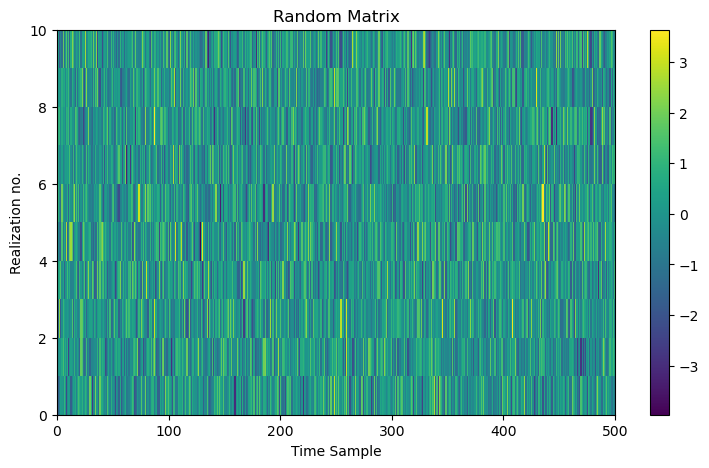

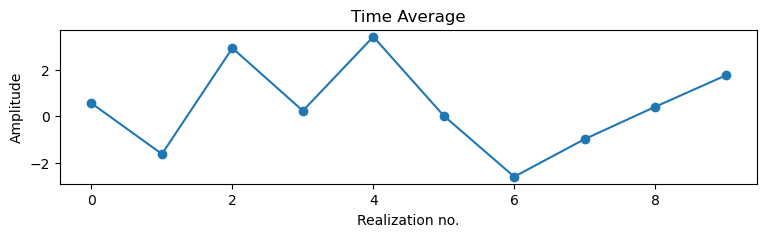

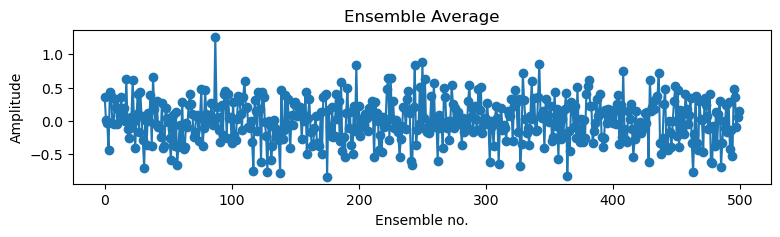

In [11]:
time_ensemble_average(10,500)

### Exercise 2.6

Define two vectors 𝐱 and 𝐲 containing normally distributed random numbers and set their length to 1000. Present the results in the form of a two-dimensional (bivariate) histogram.

In [12]:
def bivariant_hist(N):

    # Define parameters
    mu = 0.     # average
    sigma = 1.  # standard derivation

    # Compute normal distributed random numbers in vector x
    x = np.random.normal(mu, sigma, N)
    
    # Compute normal distributed random numbers in vector y
    y = np.random.normal(mu, sigma, N)
    
    # Compute optimum bin number using Freedman–Diaconis rule
    q25, q75 = np.percentile(x, [25, 75])
    bin_width = 2 * (q75 - q25) * len(x) ** (-1/3)
    bins = round((x.max() - x.min()) / bin_width)
    
    # Plot bivariant histogram
    plt.figure(figsize=(7,7))
    plt.hist2d(x,y, bins=bins)
    plt.colorbar()
    plt.ylabel('x bin')
    plt.xlabel('y bin')
    plt.title('Bivariant Histogram')
    
    plt.show()

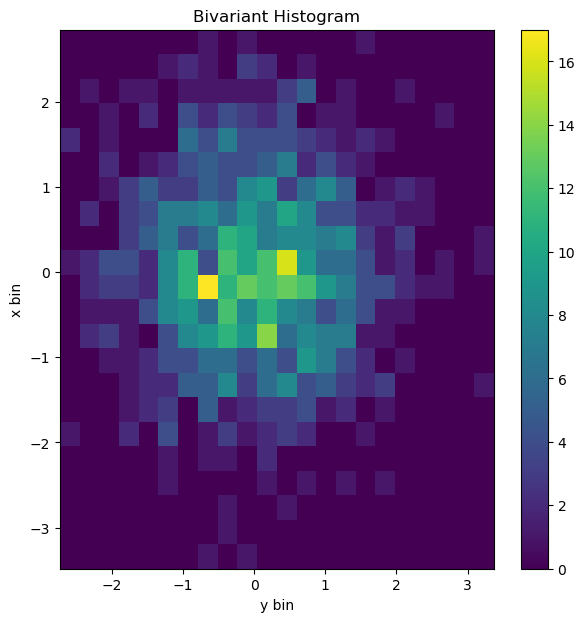

In [13]:
bivariant_hist(1000)